In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('spam.csv', encoding = 'Latin-1')

In [ ]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.shape

(5572, 5)

In [ ]:
df.keys

<bound method NDFrame.keys of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  

In [ ]:
df['Unnamed: 2'].isnull().sum()

np.int64(5522)

In [8]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace = True)

In [9]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.rename(columns = {'v1':'Target','v2':'Features'}, inplace = True)

In [11]:
df.head()

,Target,Features
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()

In [14]:
encoder.fit_transform(df['Target'])

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [15]:
df['Target'] = encoder.fit_transform(df['Target'])

In [16]:
df.head()

,Target,Features
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df['Features'].isnull().sum()

np.int64(0)

In [18]:
df.duplicated().sum()

np.int64(403)

In [19]:
df = df.drop_duplicates(keep='first')

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df

,Target,Features
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [22]:
df.shape

(5169, 2)

In [23]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

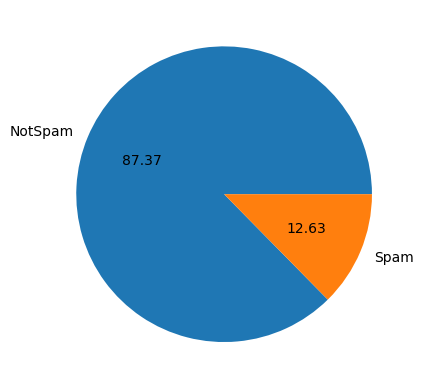

In [24]:
plt.pie(df['Target'].value_counts(), labels= ['NotSpam','Spam'],autopct='%0.2f')
plt.show()

In [25]:
import nltk
!pip install nltk

In [48]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [27]:
df = df.copy()

In [28]:
df['num_characters']= df['Features'].apply(len)

In [29]:
df

,Target,Features,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [30]:
df['Features'].apply(lambda x:len(nltk.word_tokenize(x)))

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: Features, Length: 5169, dtype: int64

In [31]:
df['num_words'] = df['Features'].apply(lambda x:len(nltk.word_tokenize(x)))

In [32]:
df

,Target,Features,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [33]:
df['num_sentences'] = df['Features'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [34]:
df.head()

,Target,Features,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [35]:
df.loc[df['Target'] == 0,['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [36]:
df.loc[df['Target'] == 1,['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: ylabel='Count'>

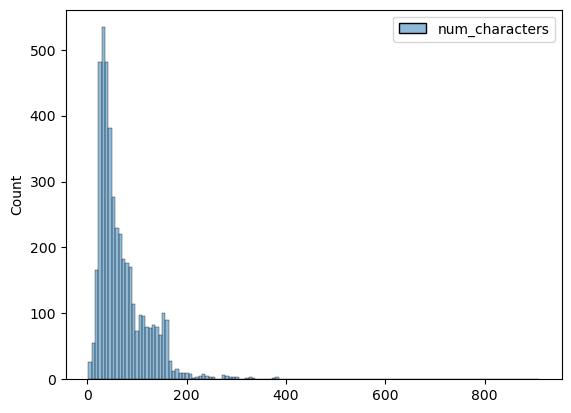

In [37]:
sns.histplot(df.loc[df['Target'] == 0, ['num_characters']])

<Axes: ylabel='Count'>

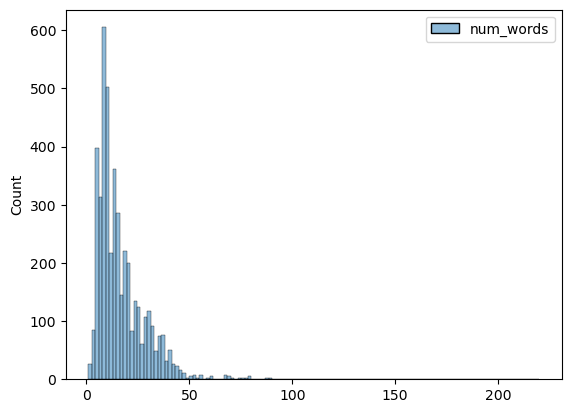

In [38]:
sns.histplot(df.loc[df['Target'] == 0, ['num_words']])

<Axes: ylabel='Count'>

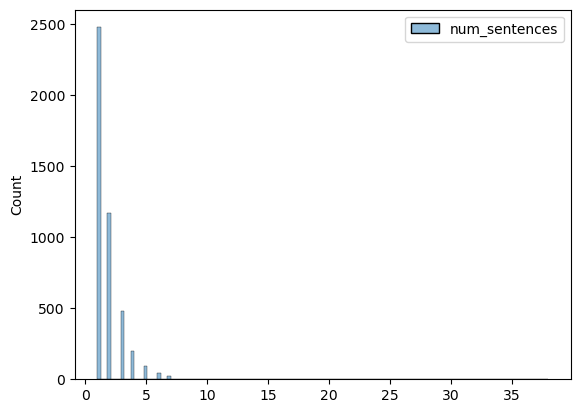

In [39]:
sns.histplot(df.loc[df['Target'] == 0, ['num_sentences']])

<Axes: ylabel='Count'>

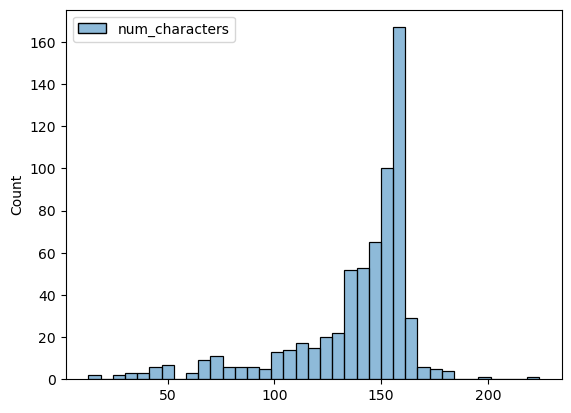

In [40]:
sns.histplot(df.loc[df['Target'] == 1, ['num_characters']])

<Axes: ylabel='Count'>

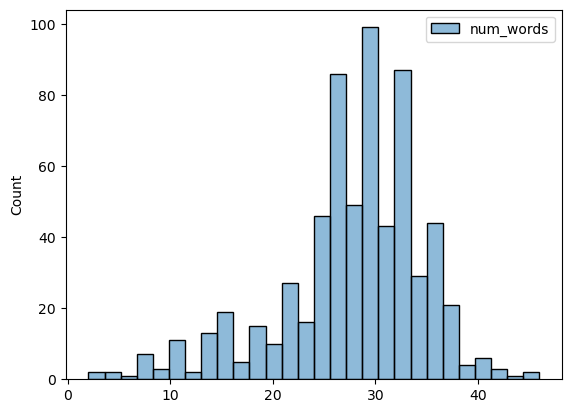

In [41]:
sns.histplot(df.loc[df['Target'] == 1, ['num_words']])

<Axes: ylabel='Count'>

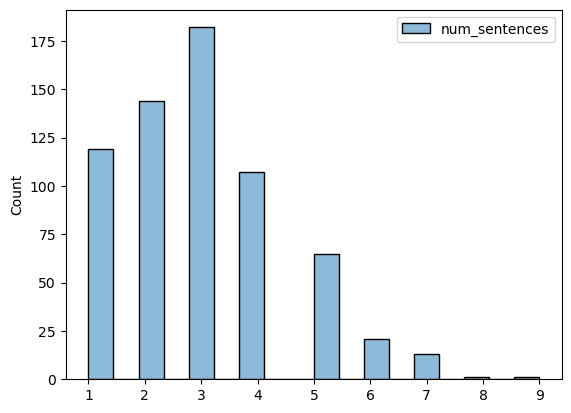

In [42]:
sns.histplot(df.loc[df['Target'] == 1, ['num_sentences']])

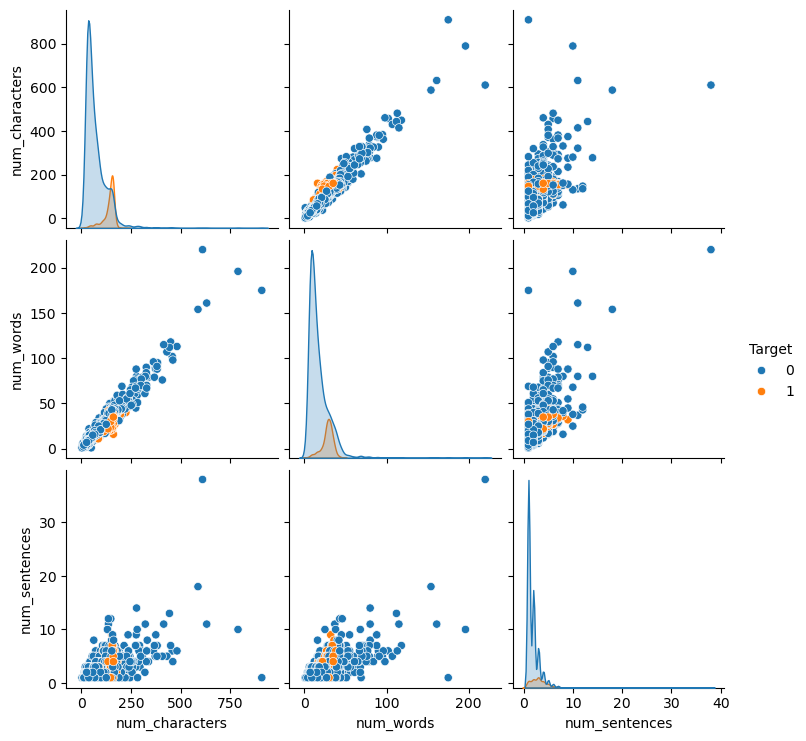

In [43]:
sns.pairplot(df,hue='Target')

In [44]:
df.corr(numeric_only = True)

,Target,num_characters,num_words,num_sentences
Target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

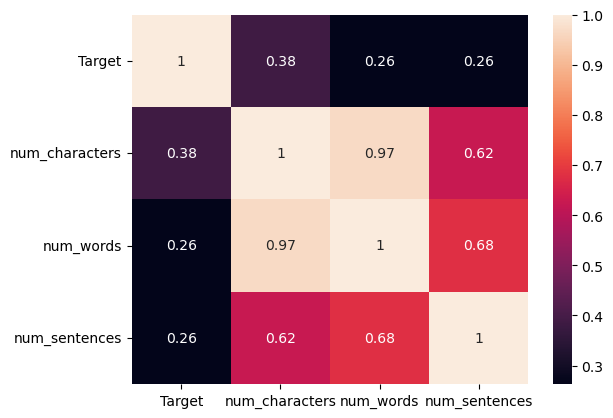

In [45]:
sns.heatmap(df.corr(numeric_only= True),annot = True)

In [49]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [50]:
def transform_text(Features):
    Features = Features.lower()
    Features = nltk.word_tokenize(Features)
    y = []
    for i in Features:
        if i.isalnum():
            y.append(i)
    Features = y[:]
    y.clear()
    for i in Features:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    Features = y[:]
    y.clear()
    for i in Features:
        y.append(ps.stem(i))
    

    return" ". join (y)

In [52]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [53]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [54]:
ps.stem("daancing")

'daanc'

In [55]:
df['Features'].apply(transform_text)

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                                b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: Features, Length: 5169, dtype: object

In [56]:
df['transform_text'] = df['Features']

In [57]:
df.head()

,Target,Features,num_characters,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...,29,8,2,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"Nah I don't think he goes to usf, he lives aro..."


In [61]:
transform_text('Hello Everyone in the %% class')

'hello everyon class'

In [75]:
from wordcloud import WordCloud
wc= WordCloud(width = 1000, height=1000, font_step=10, background_color= 'white')

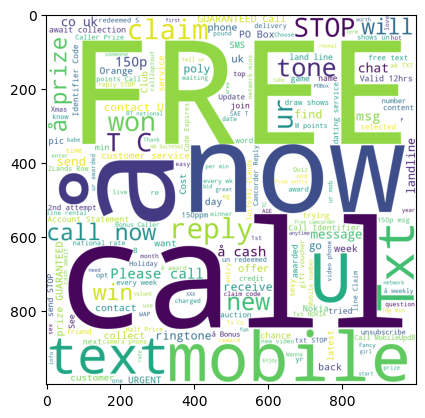

In [76]:
spam_wc = wc.generate(df[df['Target']==1]['transform_text'].str.cat(sep=''))
plt.imshow(spam_wc)

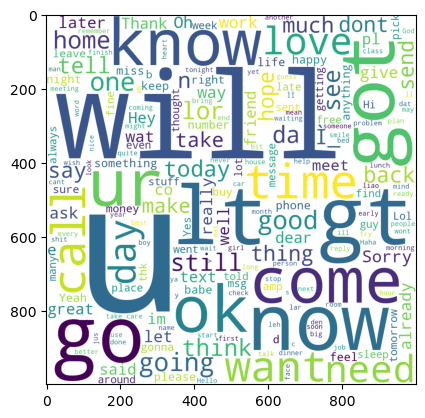

In [77]:
spam_wc = wc.generate(df[df['Target']==0]['transform_text'].str.cat(sep=''))
plt.imshow(spam_wc)

In [87]:
spam_corpus = []
for msg in df[df['Target'] == 1]['transform_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)

In [88]:
len(spam_corpus)

15464

In [84]:
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(20))

,0,1
0,to,522
1,a,314
2,your,171
3,call,163
4,the,160
5,or,155
6,for,152
7,2,151
8,you,150
9,is,130


In [85]:
ham_corpus = []
for msg in df[df['Target'] == 1]['transform_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [89]:
len(ham_corpus)

15464

In [167]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
td = TfidfVectorizer(max_features=3000)
X = td.fit_transform(df['transform_text']).toarray()

In [168]:
X.shape

(5169, 3000)

In [169]:
y = df['Target'].values

In [170]:
from sklearn.model_selection import train_test_split


In [171]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30, random_state=2)

In [172]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [173]:
gnb = GaussianNB()
mnb = MultinomialNB()
blb = BernoulliNB()

In [174]:
gnb.fit(X_train,y_train)
y_predict = gnb.predict(X_test)
print(accuracy_score(y_test,y_predict))
print(precision_score(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

0.8955512572533849
0.5505226480836237
[[1231  129]
 [  33  158]]


In [175]:
mnb.fit(X_train,y_train)
y_predict = mnb.predict(X_test)
print(accuracy_score(y_test,y_predict))
print(precision_score(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

0.9742101869761445
1.0
[[1360    0]
 [  40  151]]


In [176]:
blb.fit(X_train,y_train)
y_predict = blb.predict(X_test)
print(accuracy_score(y_test,y_predict))
print(precision_score(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

0.9851708575112831
0.9827586206896551
[[1357    3]
 [  20  171]]


In [177]:
print('tfidf is selected with mnb')

tfidf is selected with mnb


In [178]:
import pickle
pickle.dump(td,open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl','wb'))